In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,roc_curve

In [5]:
np.random.seed(42)
n=300
data = pd.DataFrame({
    "age":np.random.randint(15,60,n),
    "salary":np.random.randint(20000,100000,n),
    "balance":np.random.randint(0,200000,n),
})

data["churn"] = (
    ((data["balance"] > 100000) | (data["salary"]
                                   < 4000))
).astype(int)

data.head()

,age,salary,balance,churn
0,53,66214,42918,0
1,43,90271,52224,0
2,29,64064,39298,0
3,57,90091,80219,0
4,22,60818,61629,0


In [8]:
print(data.shape)
print(data.info())
print(data.describe())

print(data["churn"].value_counts())

(300, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   age      300 non-null    int64
 1   salary   300 non-null    int64
 2   balance  300 non-null    int64
 3   churn    300 non-null    int64
dtypes: int64(4)
memory usage: 9.5 KB
None
              age        salary        balance       churn
count  300.000000    300.000000     300.000000  300.000000
mean    37.206667  59801.330000   95385.716667    0.500000
std     13.241920  23085.437839   55295.275427    0.500835
min     15.000000  20301.000000     404.000000    0.000000
25%     25.000000  39680.500000   47571.250000    0.000000
50%     38.000000  60210.000000  100077.000000    0.500000
75%     49.000000  79048.500000  140074.750000    1.000000
max     59.000000  99909.000000  199938.000000    1.000000
churn
0    150
1    150
Name: count, dtype: int64


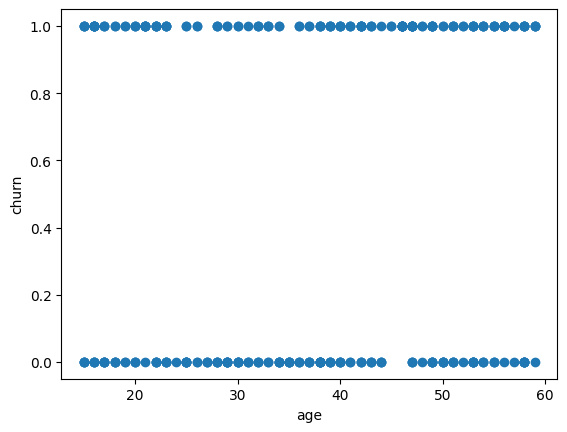

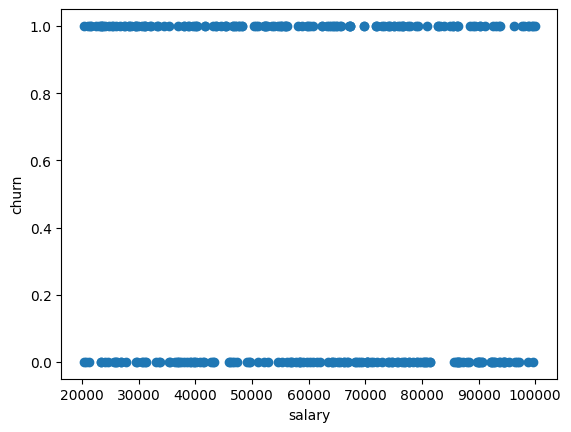

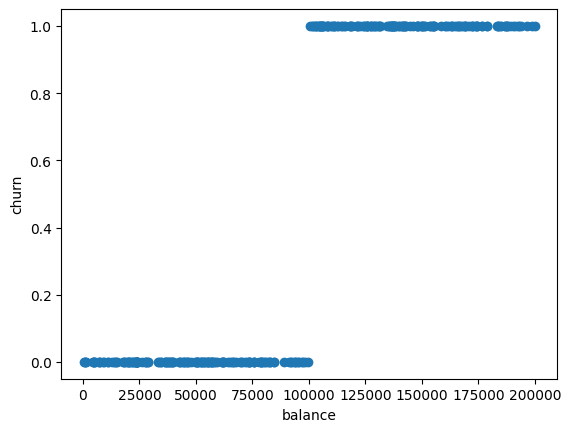

In [9]:
features = ["age","salary","balance"]

for col in features:
  plt.figure()
  plt.scatter(data[col],data["churn"])
  plt.xlabel(col)
  plt.ylabel("churn")
  plt.show()

In [10]:
x = data[["age", "salary", "balance"]]
y = data["churn"]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]
print(y_prob)

[1.00000000e+000 1.00000000e+000 1.00000000e+000 1.00000000e+000
 8.83412772e-050 0.00000000e+000 1.00000000e+000 1.00000000e+000
 6.18447637e-240 1.00000000e+000 1.00000000e+000 1.00000000e+000
 1.00000000e+000 5.02536392e-237 3.66110359e-225 1.00000000e+000
 0.00000000e+000 2.53219555e-006 1.00000000e+000 0.00000000e+000
 0.00000000e+000 9.70463434e-031 1.00000000e+000 1.00000000e+000
 0.00000000e+000 0.00000000e+000 1.00000000e+000 1.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 1.00000000e+000
 1.00000000e+000 1.00000000e+000 4.72135291e-176 0.00000000e+000
 0.00000000e+000 1.00000000e+000 1.00000000e+000 1.00000000e+000
 0.00000000e+000 1.21490213e-299 9.80841939e-042 1.00000000e+000
 0.00000000e+000 1.00000000e+000 1.00000000e+000 1.00000000e+000
 1.00000000e+000 0.00000000e+000 1.42710400e-031 0.00000000e+000
 1.00000000e+000 1.00000000e+000 1.43282978e-139 1.00000000e+000
 0.00000000e+000 3.32118289e-277 1.10899307e-203 4.00983616e-196]


In [18]:
print(x_test)
print(y_test)

     age  salary  balance
203   37   55735   137162
266   55   41677   136194
152   43   43049   125917
9     25   99909   103333
233   50   92936    91865
226   47   70517    39749
196   16   20412   104573
109   21   48251   160261
5     35   65525    66040
175   41   55195   192958
237   33   55270   141560
57    54   55777   127016
218   52   63286   142386
45    23   70336    66203
182   41   23373    70390
221   48   75069   111195
289   49   35485    47915
211   40   27357   101570
148   53   82752   174016
165   58   71991    53682
78    30   75766    50990
113   48   25949    98142
249   42   47192   190471
250   39   21062   127600
104   19   92615     8702
42    18   85726    21447
281   49   21324   169590
295   47   75771   108099
157   36   43289    19198
238   34   79163    22574
17    16   69377    20559
164   42   47663   168513
33    29   52635   199938
24    47   65714   114065
215   18   56208    75697
119   58   66175    10916
7     33   37429    23960
90    39   9

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9833333333333333
Confusion Matrix:
 [[29  0]
 [ 1 30]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       1.00      0.97      0.98        31

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60

ROC AUC Score: 1.0


In [23]:
coeff_df = pd.DataFrame({
    "Features": x.columns,
    "Coefficient": model.coef_[0]
})

print(coeff_df)

  Features  Coefficient
0      age     0.000341
1   salary     0.000850
2  balance     0.016052


In [24]:
new_data = pd.DataFrame({
    "age": [35],
    "salary": [30000],
    "balance": [150000]
})

print("Churn Prediction:",  model.predict(new_data)[0])
print("Probability:", model.predict_proba(new_data)[:, 1][0])


Churn Prediction: 1
Probability: 1.0
